In [16]:
#Install the following dependencies
#%pip install huggingface_hub
#%pip install fsspec
#%pip install pandas
#%pip install sentence-transformers
#%pip install matplotlib

In [17]:
import pandas as pd
import numpy as np
import fsspec
import huggingface_hub
from sentence_transformers import SentenceTransformer, util
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

In [18]:
#This dataframe features all the relevant questions and answers from the huggingface dataset. 
master_set_original = pd.read_csv("hf://datasets/nbertagnolli/counsel-chat/20220401_counsel_chat.csv")[['questionTitle','questionText','answerText','therapistInfo']]
question_set_df = pd.read_csv("../data/processed/question_sets/final_question_set.csv")
question_set = question_set_df[['question_title','question_text']]
master_set = pd.DataFrame()
for x in range(question_set['question_text'].size):
    add_df = master_set_original[master_set_original['questionText'].str.split().str.join(' ') == ' '.join(question_set['question_text'][x].split())]
    master_set = pd.concat([master_set, add_df], ignore_index=True)
question = (master_set['questionTitle'] + " " + master_set['questionText']).str.split().str.join(' ')
master_set.insert(0, 'question', question)
master_set = master_set.drop(['questionTitle','questionText'],axis='columns').dropna(subset=['answerText'])

#Responses to the question set from four different LLMs. 
responses_cai = pd.read_csv("../logs/responses/raw/run01/responses_s2_character_ai_member2.csv")[['input_prompt','raw_response']].rename(columns={'raw_response':'cai_response'})
responses_gpt = pd.read_csv("../logs/responses/raw/run01/responses_s2_chatgpt_member2.csv")[['input_prompt','raw_response']].rename(columns={'raw_response':'gpt_response'})
responses_claude = pd.read_csv("../logs/responses/raw/run01/responses_s2_claude_member2.csv")[['input_prompt','raw_response']].rename(columns={'raw_response':'claude_response'})
responses_gemini = pd.read_csv("../logs/responses/raw/run01/responses_s2_gemini_member2.csv")[['input_prompt','raw_response']].rename(columns={'raw_response':'gemini_response'})
ai_answer = responses_cai.merge(responses_gpt, on='input_prompt').merge(responses_claude, on='input_prompt').merge(responses_gemini, on='input_prompt')
for x in range(ai_answer['input_prompt'].size):
    ai_answer.loc[x, 'input_prompt'] = ' '.join(ai_answer.loc[x, 'input_prompt'].split())

#The questions asked
question_set = pd.Series(question.unique())

In [19]:
master_set

,question,answerText,therapistInfo
0,Is it normal to cry during therapy? I start co...,"Oh, crying in therapy is very normal! I have a...",Sue BatesChange your dating & relationship pat...
1,Is it normal to cry during therapy? I start co...,9 Ways Crying May Benefit Your HealthDetoxifie...,"Dr Traci KochendorferTime for you to "" Claim I..."
2,Is it normal to cry during therapy? I start co...,"Yes, if crying is how you are expressing an em...","David KleinHumanistic, LGBT-Affirmative Psycho..."
3,Is it normal to cry during therapy? I start co...,Please feel free to cry during therapy if you ...,"Sherry Katz, LCSWCouples and Family Therapist,..."
4,Is it normal to cry during therapy? I start co...,"People do cry in therapy sometimes, but it's n...",Miriam Dyak
...,...,...,...
263,My past is holding me back from my future. How...,"It may not feel like it, but you are in a grea...","Jessica Fealk, MA, LPCwww.dalycounseling.com (..."
264,My past is holding me back from my future. How...,I'm going to second that it is completely brav...,"Kaileen McMickle, MS, LPCLicensed Professional..."
265,My past is holding me back from my future. How...,You already are doing that! You are reaching o...,Shelly Kessingerwww.friendswoodmarriagecounsel...
266,My past is holding me back from my future. How...,I'm so sorry you had that horrible experience!...,Amy StandiferChristian Sex Therapist and Certi...


In [20]:
ai_answer

,input_prompt,cai_response,gpt_response,claude_response,gemini_response
0,Is it normal to cry during therapy? I start co...,It's totally normal to cry during therapy. In...,It’s completely normal to cry during therapy—m...,It's completely normal to cry during therapy —...,"First off, take a deep breath. What you’re fee..."
1,How do I cope with separation anxiety while bo...,"hey, first—i’m really glad you shared this. it...",Dealing with separation anxiety when your part...,I hear how painful this is for you. The shift ...,I’m so sorry you’re feeling this way. It is co...
2,Is it normal to go into therapy feeling nervou...,100% normal. Seriously — welcome to the club! ...,"Yes, it’s completely normal to feel nervous wh...","Yes, this is completely normal! Feeling nervou...","First of all, take a deep breath. What you’re ..."
3,How is it that I fear going to sleep? I just a...,"hey, that’s actually really common — what you’...",It sounds like you're experiencing what might ...,This sounds like it could be a few different t...,It is incredibly frustrating to be on the verg...
4,Can I change my feeling of being worthless to ...,It can be a good way of releasing your thought...,"I'm so sorry you're feeling this way, and I wa...","I'm really glad you reached out, and I want yo...",I am so sorry you’re carrying such a heavy wei...
5,Do I have too many issues for counseling? I ha...,"No, of course not! Your story is a very real o...","First, let me say that it takes courage to rec...","No, you absolutely don't have too many issues ...","First, I want to acknowledge the incredible re..."
6,How can I best fight the winter blues? Every w...,winter blues also known as seasonal depression...,"Winter blues, also known as seasonal affective...",I completely understand — winter can be really...,"It is completely valid to feel a bit ""under th..."
7,How can I stop treating people badly? I feel l...,Sounds like a lot of pain. Can you say more ab...,"I'm so sorry you're feeling this way, and I wa...","I hear you, and I want you to know that recogn...","First off, I want to acknowledge how much cour..."
8,"I lost my mom, and I feel like I'm depressed L...",It's understandable that you're feeling depres...,I'm so sorry you're feeling this way. Losing y...,I'm really sorry for the loss of your mother. ...,I am so deeply sorry for your loss. Losing a m...
9,How do I stop grieving my mother’s death? What...,I'm so sorry to hear about your mother's passi...,I'm so sorry you're going through this pain. L...,I'm truly sorry for the loss of your mother. T...,I am so deeply sorry for the loss of your moth...


In [21]:
question_set

0     Is it normal to cry during therapy? I start co...
1     How do I cope with separation anxiety while bo...
2     Is it normal to go into therapy feeling nervou...
3     How is it that I fear going to sleep? I just a...
4     Can I change my feeling of being worthless to ...
5     Do I have too many issues for counseling? I ha...
6     How can I best fight the winter blues? Every w...
7     How can I stop treating people badly? I feel l...
8     I lost my mom, and I feel like I'm depressed L...
9     How do I stop grieving my mother’s death? What...
10    How do I find happiness after my boyfriend pas...
11    How can I ask my boyfriend about who he's text...
12    My girlfriend is always accusing me of cheatin...
13    My fiancé cheated. How can we mend our relatio...
14    I'm with someone, but I have unresolved feelin...
15    How can my boyfriend forgive me when I can't f...
16    I weigh over 220 pounds and I am 16 years old ...
17    How do I cope with "never being good enoug

In [22]:
#cosine similarity using Sentence Transformers
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3396.38it/s]


In [23]:
results = {} #Results of the cosine similarity between therapist and AI responses
ai_vs_ai_results = {} #Cosine similarity between AI responses
all_responses = {} #List of all responses, for use in the Google Form survey. Unused in the final survey but kept because I like it
all_responses_truncated = {} # List of all responses, limit of 5 (each of the 4 AI answers plus 1 random therapist answer). This was decided as
#there were simply too many therapist answers to evaluate
for x in range(question_set.size):
    therapist_answers = master_set[master_set['question'] == question_set[x]]['answerText'].to_numpy()
    cai_answers = ai_answer[ai_answer['input_prompt'] == question_set[x]]['cai_response'].to_numpy()
    gpt_answers = ai_answer[ai_answer['input_prompt'] == question_set[x]]['gpt_response'].to_numpy()
    claude_answers = ai_answer[ai_answer['input_prompt'] == question_set[x]]['claude_response'].to_numpy()
    gemini_answers = ai_answer[ai_answer['input_prompt'] == question_set[x]]['gemini_response'].to_numpy()
    embeddings_therapist = model.encode(therapist_answers)
    embeddings_cai = model.encode(cai_answers)
    embeddings_gpt = model.encode(gpt_answers)
    embeddings_claude = model.encode(claude_answers)
    embeddings_gemini = model.encode(gemini_answers)

    similarities_cai = model.similarity(embeddings_cai,embeddings_therapist)[0].numpy()
    similarities_gpt = model.similarity(embeddings_gpt,embeddings_therapist)[0].numpy()
    similarities_claude = model.similarity(embeddings_claude,embeddings_therapist)[0].numpy()
    similarities_gemini = model.similarity(embeddings_gemini,embeddings_therapist)[0].numpy()



    ai_array = np.vstack((np.vstack((similarities_cai,similarities_gpt)),np.vstack((similarities_claude,similarities_gemini))))

    results[question_set[x]] = ai_array

    all_ai = np.vstack([embeddings_cai, embeddings_gpt, embeddings_claude, embeddings_gemini])
    ai_vs_ai_results[question_set[x]] = model.similarity(all_ai, all_ai).numpy()

    
    responses = np.append(np.append(np.append(therapist_answers,cai_answers),np.append(gpt_answers,claude_answers)),gemini_answers)
    np.random.shuffle(responses)
    all_responses[question_set[x]] = [responses]

    np.random.shuffle(therapist_answers)
    responses_truncated = np.append(therapist_answers[0:1],np.append(np.append(cai_answers,gpt_answers),np.append(claude_answers,gemini_answers)))
    all_responses_truncated[question_set[x]] = [responses_truncated]

In [24]:
#csv table that acts as a guide for scenario 2's therapist responses
for number in range(question_set.size):
    response_number = [f"R{i+1}" for i in range(results[question_set[number]].T.shape[0])]
    guide_csv = master_set[master_set['question'] == question_set[number]].rename(columns={'question' : 'Question', 'answerText' : 'Answer', 'therapistInfo' : 'Therapist'})
    guide_csv['Response Number'] = response_number
    guide_csv.set_index('Response Number', inplace=True)
    guide_csv.to_csv(f'../data/processed/Therapist Responses/Prompt {number+1}.csv')

In [25]:
#Heatmaps comparing each AI response with therapist responses
ai_models = ["Character.AI", "ChatGPT", "Claude", "Gemini"]
for number in range(question_set.size):
    array = results[question_set[number]].T 

    responses = [f"R{i+1}" for i in range(array.shape[0])]

    fig, ax = plt.subplots(figsize=(8, max(4, len(responses) * 0.5)))
    im = ax.imshow(array, vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(ai_models)), labels=ai_models, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(responses)), labels=responses)

    for i in range(len(responses)):
        for j in range(len(ai_models)):
            text = ax.text(j, i, f"{array[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)

    fig.colorbar(im, ax=ax, label="Cosine Similarity")
    ax.set_title(f"AI vs Therapist Responses\nPrompt {number+1}")
    fig.tight_layout()
    plt.savefig(f"../results/Scenario 2/Heat Maps/AI vs Therapist Prompt {number+1}.png")
    plt.close()

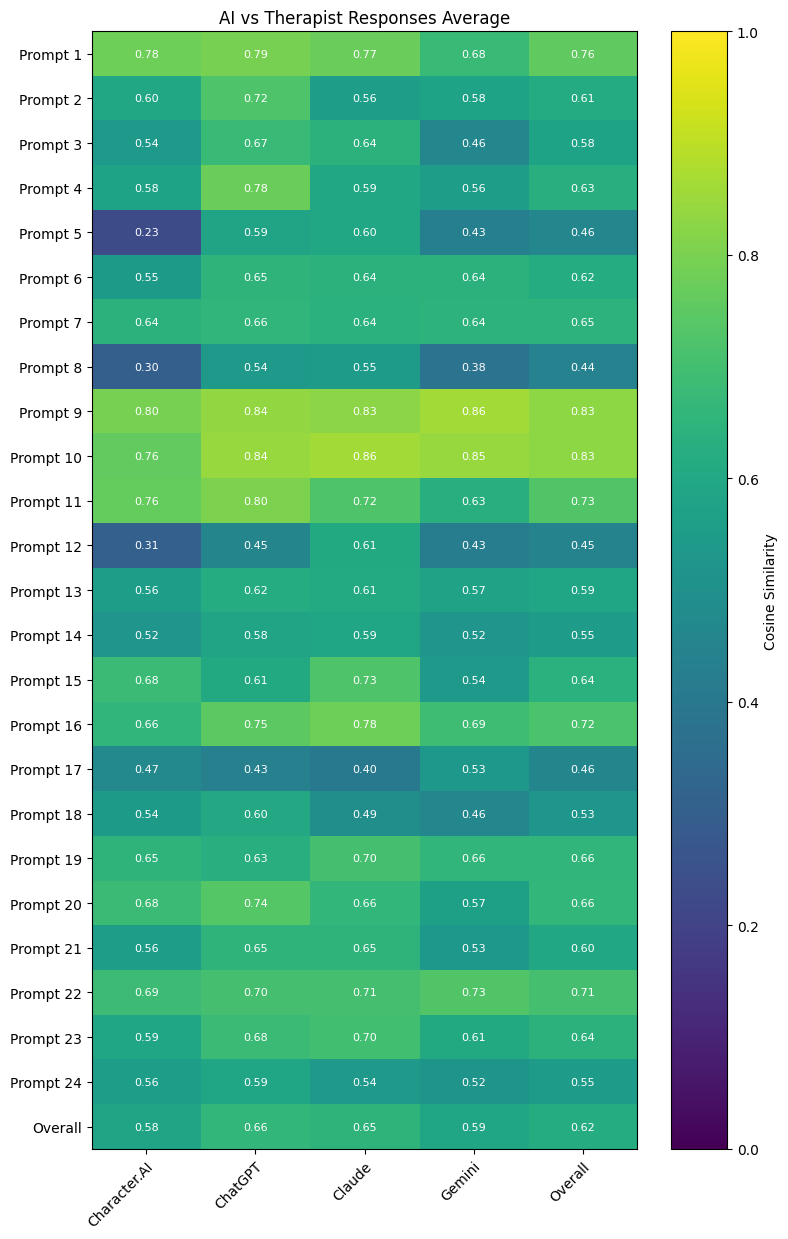

In [26]:
#Single heatmap average
avg_array = []
ai_models = ["Character.AI", "ChatGPT", "Claude", "Gemini", "Overall"]
for number in range(question_set.size):
    average = np.mean(results[question_set[number]],axis=1)
    avg_array.append(np.append(average,[average.mean()]))
avg_array = np.array(avg_array)
avg_array = np.append(avg_array, [np.mean(avg_array,axis=0)],axis=0)
prompts = [f"Prompt {i+1}" for i in range(question_set.size)]
prompts.append('Overall')

fig, ax = plt.subplots(figsize=(8, max(4, len(prompts) * 0.5)))
im = ax.imshow(avg_array, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(ai_models)), labels=ai_models, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(prompts)), labels=prompts)

for i in range(len(prompts)):
        for j in range(len(ai_models)):
            text = ax.text(j, i, f"{avg_array[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)

fig.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title(f"AI vs Therapist Responses Average")
fig.tight_layout()
plt.savefig(f"../results/Scenario 2/Heat Maps/AI vs Therapist Average Across All Prompts.png")


In [27]:
#Heatmaps comparing AI responses to each other
ai_models = ["Character.AI", "ChatGPT", "Claude", "Gemini"]
for number in range(question_set.size):
    array = ai_vs_ai_results[question_set[number]]

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(array, vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(ai_models)), labels=ai_models, rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(len(ai_models)), labels=ai_models)

    for i in range(len(ai_models)):
        for j in range(len(ai_models)):
            text = ax.text(j, i, f"{array[i, j]:.2f}", ha="center", va="center", color="w", fontsize=9)

    fig.colorbar(im, ax=ax, label="Cosine Similarity")
    ax.set_title(f"AI vs AI Responses\nPrompt {number+1}")
    fig.tight_layout()
    plt.savefig(f"../results/Scenario 2/Heat Maps/AI vs AI Prompt {number+1}.png")
    plt.close()

avg_ai_vs_ai = np.mean([ai_vs_ai_results[question_set[num]] for num in range(question_set.size)], axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(avg_ai_vs_ai, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(ai_models)), labels=ai_models, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(ai_models)), labels=ai_models)

for i in range(len(ai_models)):
    for j in range(len(ai_models)):
        text = ax.text(j, i, f"{avg_ai_vs_ai[i, j]:.2f}", ha="center", va="center", color="w", fontsize=9)

fig.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("AI vs AI Responses Average Across All Prompts")
fig.tight_layout()
plt.savefig("../results/Scenario 2/Heat Maps/AI vs AI Average Across All Prompts.png")
plt.close()


In [28]:
all_responses_df = pd.DataFrame()
for num in range(question_set.size):
    for entity in all_responses[question_set[num]][0]:
        row = pd.DataFrame([[question_set[num], entity]], columns=['question', 'response'])
        all_responses_df = pd.concat([all_responses_df, row], ignore_index=True)


In [29]:
all_responses_df
all_responses_df.to_csv('../data/processed/all_responses.csv',index=False)

In [30]:
all_responses_truncated_df = pd.DataFrame()
for num in range(question_set.size):
    for entity in all_responses_truncated[question_set[num]][0]:
        row = pd.DataFrame([[question_set[num], entity]], columns=['question', 'response'])
        all_responses_truncated_df = pd.concat([all_responses_truncated_df, row], ignore_index=True)

In [31]:
#all_responses_truncated_df.to_csv('../data/processed/all_responses_truncated.csv',index=False)

In [32]:
for num in range(question_set.size):
    print(f"Prompt {num+1}:", all_responses[question_set[num]][0].size-4, "real-life therapist responses total")

Prompt 1: 14 real-life therapist responses total
Prompt 2: 5 real-life therapist responses total
Prompt 3: 28 real-life therapist responses total
Prompt 4: 2 real-life therapist responses total
Prompt 5: 35 real-life therapist responses total
Prompt 6: 86 real-life therapist responses total
Prompt 7: 18 real-life therapist responses total
Prompt 8: 1 real-life therapist responses total
Prompt 9: 2 real-life therapist responses total
Prompt 10: 1 real-life therapist responses total
Prompt 11: 1 real-life therapist responses total
Prompt 12: 6 real-life therapist responses total
Prompt 13: 4 real-life therapist responses total
Prompt 14: 4 real-life therapist responses total
Prompt 15: 1 real-life therapist responses total
Prompt 16: 2 real-life therapist responses total
Prompt 17: 2 real-life therapist responses total
Prompt 18: 5 real-life therapist responses total
Prompt 19: 10 real-life therapist responses total
Prompt 20: 2 real-life therapist responses total
Prompt 21: 5 real-life 

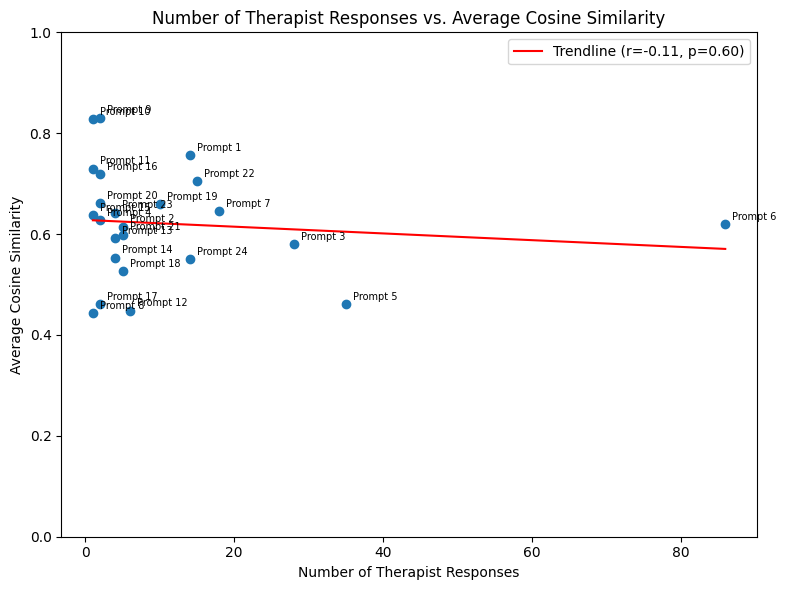

In [34]:
num_responses = [all_responses[question_set[num]][0].size - 4 for num in range(question_set.size)]
avg_scores = [avg_array[num][4] for num in range(question_set.size)]
prompt_labels = [f"Prompt {i+1}" for i in range(question_set.size)]

slope, intercept, r_value, p_value, std_err = stats.linregress(num_responses, avg_scores)
x_line = np.linspace(min(num_responses), max(num_responses), 200)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(num_responses, avg_scores)
ax.plot(x_line, y_line, color="red", linewidth=1.5, label=f"Trendline (r={r_value:.2f}, p={p_value:.2f})")

for i, label in enumerate(prompt_labels):
    ax.annotate(label, (num_responses[i], avg_scores[i]), textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.set_xlabel("Number of Therapist Responses")
ax.set_ylabel("Average Cosine Similarity")
ax.set_title("Number of Therapist Responses vs. Average Cosine Similarity")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
plt.savefig("../results/Scenario 2/Number of Therapist Responses vs Average Cosine Similarity.png")
plt.show()